# Exercise 7.2 — Pricing Swaptions: Solution
**Date:** 2025-06-30  
**Swaption:** Payer swaption, 1yr expiry × 4yr swap tenor (quarterly payments, SOFR)

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

cc = pd.read_excel('cap_curves_2025-06-30.xlsx')
sv = pd.read_excel('swaption_vol_data_2025-06-30.xlsx')

## Helper Functions

In [5]:
def get_discount(t):
    """Linearly interpolate discount factor Z(0,t) from curve data."""
    return np.interp(t, cc['tenor'], cc['discounts'])

def compute_fwd_swap(T_exp, tenor, freq=4):
    """
    Compute the forward swap rate and annuity for a swap
    starting at T_exp with given tenor (years) and payment frequency per year.
    
    Forward Swap Rate:  S = (Z(0, T_exp) - Z(0, T_exp+tenor)) / Annuity
    Annuity:            A = sum_i [ dt * Z(0, t_i) ]  for each payment date t_i
    """
    dt = 1.0 / freq
    T_end = T_exp + tenor
    payment_dates = np.arange(T_exp + dt, T_end + 1e-9, dt)
    Z_exp = get_discount(T_exp)
    Z_end = get_discount(T_end)
    annuity = sum(dt * get_discount(t) for t in payment_dates)
    fsr = (Z_exp - Z_end) / annuity
    return fsr, annuity, Z_exp, Z_end

def black_payer(F, K, sigma, T, annuity):
    """
    Black's formula for a payer swaption (per unit notional).
    
    Price = Annuity * [ F * N(d1) - K * N(d2) ]
    d1 = [ ln(F/K) + 0.5*sigma^2*T ] / (sigma*sqrt(T))
    d2 = d1 - sigma*sqrt(T)
    """
    if sigma <= 0 or T <= 0:
        return max(F - K, 0) * annuity
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return annuity * (F * norm.cdf(d1) - K * norm.cdf(d2))

---
## 1.1 — Forward Swap Rate (1yr × 4yr)

In [6]:
T_exp, tenor = 1.0, 4.0
fsr, annuity, Z_exp, Z_end = compute_fwd_swap(T_exp, tenor)

print('Forward Swap Rate  (1yr × 4yr, quarterly)')
print('=' * 45)
print(f'  Z(0, 1) = {Z_exp:.6f}')
print(f'  Z(0, 5) = {Z_end:.6f}')
print(f'  Annuity = {annuity:.6f}')
print(f'  Forward Swap Rate S = (Z1 - Z5) / A')
print(f'                      = ({Z_exp:.6f} - {Z_end:.6f}) / {annuity:.6f}')
print(f'                      = {fsr*100:.4f}%')

Forward Swap Rate  (1yr × 4yr, quarterly)
  Z(0, 1) = 0.962807
  Z(0, 5) = 0.844989
  Annuity = 3.603238
  Forward Swap Rate S = (Z1 - Z5) / A
                      = (0.962807 - 0.844989) / 3.603238
                      = 3.2698%


The **1-year forward 4-year swap rate** is calculated as:

$$S_{1\times 5} = \frac{Z(0,1) - Z(0,5)}{\sum_{i=1}^{16} \frac{1}{4} \cdot Z(0, T_i)}$$

where the 16 quarterly payment dates $T_i$ run from 1.25yr to 5.00yr. This equals **3.2698%**.

---
## 1.2 — Swaption Prices at All Quoted Strikes

In [7]:
row_1x4 = sv[(sv['expiration'] == 1) & (sv['tenor'] == 4)].iloc[0]
strike_offsets = [-200, -100, -50, -25, 0, 25, 50, 100, 200]

results = []
for sc in strike_offsets:
    K = fsr + sc / 10000
    vol = row_1x4[sc] / 100
    price = black_payer(fsr, K, vol, T_exp, annuity)
    results.append({'Strike Offset (bps)': sc,
                    'Strike (%)': K * 100,
                    'Black Vol (%)': vol * 100,
                    'Price (bps notional)': price * 10000})

df_results = pd.DataFrame(results)
print(f'ATM Forward Swap Rate = {fsr*100:.4f}%')
print(f'Expiry = 1yr  |  Tenor = 4yr  |  Quarterly  |  Payer Swaption\n')
print(df_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

ATM Forward Swap Rate = 3.2698%
Expiry = 1yr  |  Tenor = 4yr  |  Quarterly  |  Payer Swaption

 Strike Offset (bps)  Strike (%)  Black Vol (%)  Price (bps notional)
                -200      1.2698        54.4050              727.1096
                -100      2.2698        38.5650              394.8049
                 -50      2.7698        33.9250              253.6235
                 -25      3.0198        32.1950              194.3130
                   0      3.2698        30.8300              144.3366
                  25      3.5198        29.8050              104.2391
                  50      3.7698        29.0950               73.6560
                 100      4.2698        28.4300               35.5738
                 200      5.2698        28.8850                8.7983


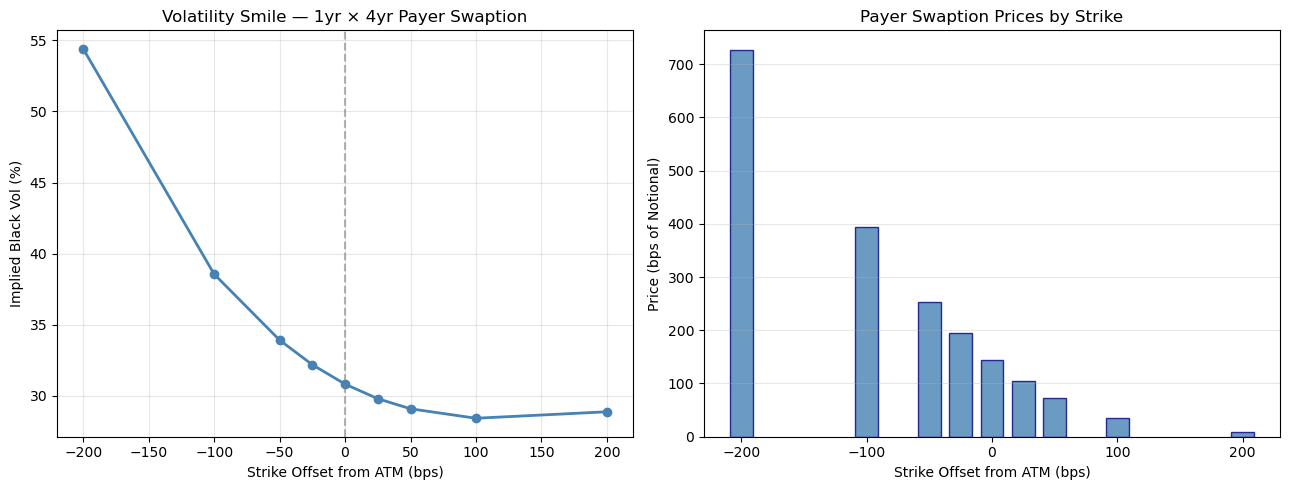

Figure saved.


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

strikes_pct = df_results['Strike (%)'].values
vols = df_results['Black Vol (%)'].values
prices = df_results['Price (bps notional)'].values

ax1.plot(df_results['Strike Offset (bps)'], vols, 'o-', color='steelblue', lw=2)
ax1.axvline(0, color='gray', ls='--', alpha=0.6)
ax1.set_xlabel('Strike Offset from ATM (bps)')
ax1.set_ylabel('Implied Black Vol (%)')
ax1.set_title('Volatility Smile — 1yr × 4yr Payer Swaption')
ax1.grid(alpha=0.3)

ax2.bar(df_results['Strike Offset (bps)'], prices, width=18, color='steelblue', alpha=0.8, edgecolor='navy')
ax2.set_xlabel('Strike Offset from ATM (bps)')
ax2.set_ylabel('Price (bps of Notional)')
ax2.set_title('Payer Swaption Prices by Strike')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('swaption_smile_and_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

**Key observations:**
- The vol smile is **downward-sloping** (left skew): out-of-the-money payers (negative offset, lower strike) command higher implied vols — this is the **receiver skew** typical in swaption markets.
- The ATM price at **30.83% vol** gives **144.3 bps** of notional.
- Deep OTM payers (+200 bps over ATM) cost only **8.8 bps**, while deep ITM (-200 bps) cost **727 bps** reflecting mostly intrinsic value.


---
## 1.3 — Comparison Across Expiry and Tenor

In [11]:
atm_vol = row_1x4[0] / 100  # ATM vol from 1x4

configs = [
    (0.25, 4.0, '3mo × 4yr'),
    (1.0,  4.0, '1yr × 4yr ← base'),
    (2.0,  4.0, '2yr × 4yr'),
    (1.0,  2.0, '1yr × 2yr'),
]

comp = []
for T_e, ten, label in configs:
    f, ann, _, _ = compute_fwd_swap(T_e, ten)
    p = black_payer(f, f, atm_vol, T_e, ann)
    comp.append({'Swaption': label, 'Fwd Rate (%)': f*100,
                 'Annuity': ann, 'ATM Vol (%)': atm_vol*100,
                 'ATM Price (bps)': p*10000})

df_comp = pd.DataFrame(comp)
print(f'Vol used for all: {atm_vol*100:.2f}% (ATM vol from 1yr × 4yr row)\n')
print(df_comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Vol used for all: 30.83% (ATM vol from 1yr × 4yr row)

        Swaption  Fwd Rate (%)  Annuity  ATM Vol (%)  ATM Price (bps)
       3mo × 4yr        3.2998   3.6922      30.8300          74.8498
1yr × 4yr ← base        3.2698   3.6032      30.8300         144.3366
       2yr × 4yr        3.4257   3.4845      30.8300         205.9942
       1yr × 2yr        3.1183   1.8605      30.8300          71.0757


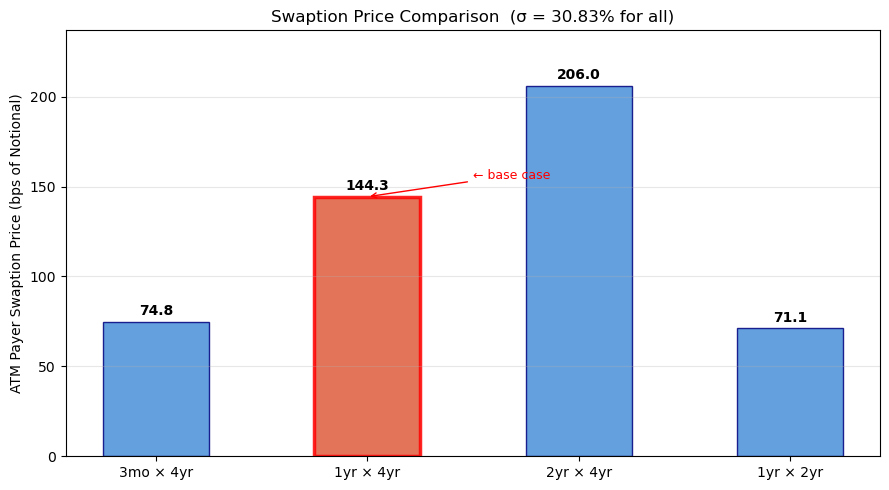

Figure saved.


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = [c[2].replace(' ← base','') for c in configs]
prices_comp = df_comp['ATM Price (bps)'].values
colors = ['#4a90d9', '#e05c3c', '#4a90d9', '#4a90d9']

bars = ax.bar(labels, prices_comp, color=colors, alpha=0.85, edgecolor='navy', width=0.5)
for bar, val in zip(bars, prices_comp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('ATM Payer Swaption Price (bps of Notional)')
ax.set_title(f'Swaption Price Comparison  (σ = {atm_vol*100:.2f}% for all)')
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, max(prices_comp)*1.15)
bars[1].set_edgecolor('red')
bars[1].set_linewidth(2.5)
ax.annotate('← base case', xy=(1, prices_comp[1]), xytext=(1.5, prices_comp[1]+10),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('swaption_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

### Interpretation

| Swaption | Price (bps) | vs Base | Why |
|---|---|---|---|
| **3mo × 4yr** | 74.8 | −69.5 | Much shorter expiry → far less time for rates to move; `sqrt(T)` effect |
| **1yr × 4yr** | 144.3 | — | **Base case** |
| **2yr × 4yr** | 206.0 | +61.6 | Longer expiry → more time value; but fwd rate is slightly higher too |
| **1yr × 2yr** | 71.1 | −73.2 | Same expiry & vol, but annuity is ~half the size (only 8 payment dates vs 16) |

**Key takeaways:**
1. **Expiry effect**: Holding tenor fixed, ATM swaption price grows with `sqrt(T_exp)` × Annuity × F × σ.  The 2yr expiry costs ~43% more than the 1yr, roughly consistent with `sqrt(2)/sqrt(1) ≈ 1.41`.
2. **Tenor effect**: Holding expiry fixed, a longer tenor increases the **annuity** (more payment periods discounted), which scales the dollar price up proportionally. The 1yr × 2yr swaption has roughly half the annuity of the 1yr × 4yr, and its price is approximately half.
3. **Vol effect**: Only one vol is used here for comparability — in practice each swaption has its own ATM vol, which would also differ across expiries/tenors.